# 02 · Preprocesamiento y features

Deriva, a partir de `data/_processed/01_raw_clean.csv`, las mismas features numéricas/binarias que usa la app en producción (`app/domain/ml_features.FEATURE_NAMES` + `LIFESTYLE_FEATURES`), y calcula las medianas de imputación que se usarán tanto para el clustering (notebook 03) como para el modelo final (notebook 04).

**Salida:** `data/_processed/02_features.csv`.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 30)

df = pd.read_csv('../data/_processed/01_raw_clean.csv')
print('shape:', df.shape)

shape: (16175, 20)


## Features clínicas + síntomas gastrointestinales

Estas 11 features son las que finalmente usa el modelo (ver notebook 03: son el subconjunto con mejor silueta e interpretación clínica).

In [2]:
def has_any(text, needles):
    t = str(text).lower()
    return any(n in t for n in needles)

df['usa_hipoglicemiante'] = df['medicamentos'].apply(lambda t: int(has_any(t, ['hipoglicemiante'])))
df['usa_hipolipemiante'] = df['medicamentos'].apply(lambda t: int(has_any(t, ['hipolipemiante'])))
df['usa_antiacido_ibp'] = df['medicamentos'].apply(lambda t: int(has_any(t, ['antiácid', 'antiacid', 'bomba de protones'])))
df['n_sintomas_gi'] = df['sintomas_gi'].apply(
    lambda t: 0 if 'ninguno' in str(t).lower() else len([p for p in str(t).split(';') if p.strip()])
)

CLINICAL_GI_FEATURES = [
    'imc', 'perimetro', 'pa_sistolica', 'pa_diastolica',
    'colesterol_total', 'colesterol_hdl', 'hba1c',
    'usa_hipoglicemiante', 'usa_hipolipemiante', 'n_sintomas_gi', 'usa_antiacido_ibp',
]
df[CLINICAL_GI_FEATURES].describe().round(2)

,imc,perimetro,pa_sistolica,pa_diastolica,colesterol_total,colesterol_hdl,hba1c,usa_hipoglicemiante,usa_hipolipemiante,n_sintomas_gi,usa_antiacido_ibp
count,16175.00,16175.00,16175.00,16175.00,16175.00,16175.00,16175.00,16175.00,16175.00,16175.00,16175.0
mean,28.39,90.82,118.35,77.01,193.05,49.25,5.59,0.14,0.26,0.63,0.1
std,5.70,13.77,7.93,5.63,40.51,11.76,0.59,0.35,0.44,1.45,0.3
min,14.44,41.00,84.00,50.00,67.00,19.00,4.00,0.00,0.00,0.00,0.0
25%,24.34,81.00,118.00,76.00,167.00,41.00,5.30,0.00,0.00,0.00,0.0
50%,27.48,90.00,118.00,78.00,192.00,48.00,5.50,0.00,0.00,0.00,0.0
75%,31.85,99.00,120.00,80.00,215.00,55.00,5.70,0.00,1.00,0.00,0.0
max,65.57,195.00,240.00,120.00,423.00,133.00,14.40,1.00,1.00,11.00,1.0


## Features de estilo de vida (para explicar, no para clusterizar — ver notebook 03)

In [3]:
df['n_habitos'] = df['habitos'].apply(
    lambda t: 0 if 'ninguno' in str(t).lower() else len([p for p in str(t).split(';') if p.strip()])
)
df['hace_actividad'] = (~df['tipo_actividad'].str.lower().str.contains('ninguno', na=False)).astype(int)
df['actividad_fuerza'] = df['tipo_actividad'].apply(lambda t: int(has_any(t, ['fuerza'])))
freq_map = {'ninguno': 0, '1 vez': 1, '2 veces': 2, '3 veces': 3, '4 veces': 4, '5 o más veces': 5}
df['frecuencia_actividad_num'] = (
    df['frecuencia_actividad'].str.strip().str.lower().str.rstrip(';').map(freq_map).fillna(0)
)
df['estres_alto_bin'] = (df['estres_alto'].str.strip().str.upper() == 'SÍ').astype(int)
df['ansioso_bin'] = (df['ansioso'].str.strip().str.upper() == 'SÍ').astype(int)
df['nervioso_bin'] = (df['nervioso'].str.strip().str.upper() == 'SÍ').astype(int)
df['tecnica_estres_bin'] = (df['tecnica_estres'].str.strip().str.upper() == 'SÍ').astype(int)

LIFESTYLE_FEATURES = [
    'estres_alto_bin', 'ansioso_bin', 'nervioso_bin', 'tecnica_estres_bin',
    'hace_actividad', 'actividad_fuerza', 'frecuencia_actividad_num', 'n_habitos',
]
df[LIFESTYLE_FEATURES].describe().round(2)

,estres_alto_bin,ansioso_bin,nervioso_bin,tecnica_estres_bin,hace_actividad,actividad_fuerza,frecuencia_actividad_num,n_habitos
count,16175.00,16175.0,16175.00,16175.00,16175.00,16175.00,16175.00,16175.00
mean,0.17,0.5,0.48,0.15,0.62,0.14,0.24,2.22
std,0.37,0.5,0.50,0.36,0.49,0.35,0.92,1.78
min,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.0,0.00,0.00,1.00,0.00,0.00,2.00
75%,0.00,1.0,1.00,0.00,1.00,0.00,0.00,4.00
max,1.00,1.0,1.00,1.00,1.00,1.00,5.00,6.00


## Matriz de correlación

Sirve para entender qué tan redundantes son las features clínicas entre sí y frente a las de estilo de vida — motiva por qué en el notebook 03 se comparan varios subconjuntos en vez de asumir que todas aportan por igual.

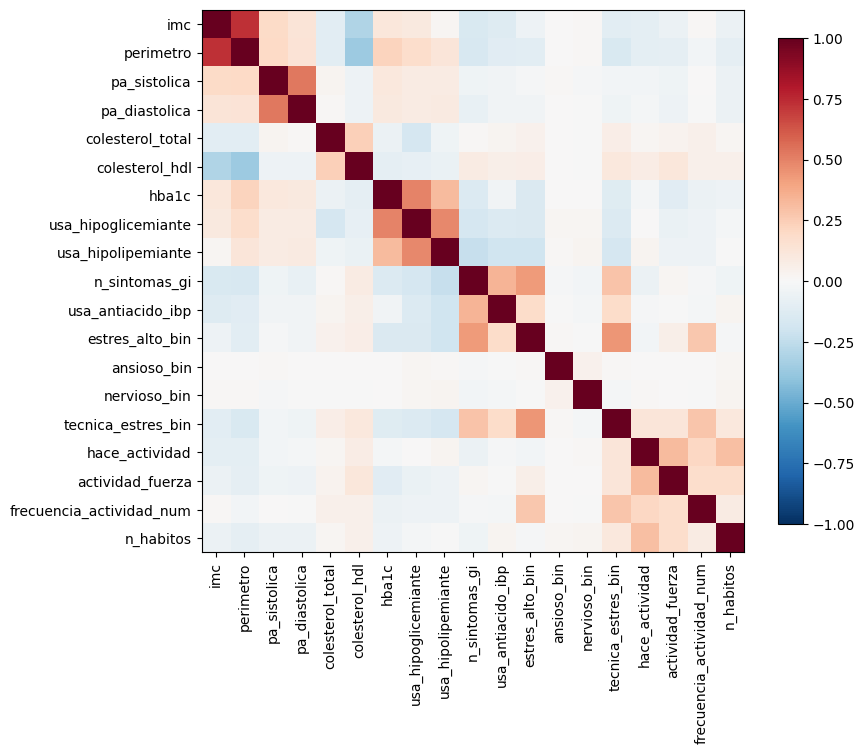

In [4]:
all_features = CLINICAL_GI_FEATURES + LIFESTYLE_FEATURES
corr = df[all_features].corr()
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(all_features))); ax.set_xticklabels(all_features, rotation=90)
ax.set_yticks(range(len(all_features))); ax.set_yticklabels(all_features)
fig.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()

In [5]:
# Pares con mayor correlación (fuera de la diagonal)
pairs = corr.where(~np.eye(len(corr), dtype=bool)).unstack().dropna()
pairs = pairs[pairs.index.get_level_values(0) < pairs.index.get_level_values(1)]
pairs.sort_values(key=abs, ascending=False).head(10)

imc                  perimetro              0.728800
pa_diastolica        pa_sistolica           0.523755
hba1c                usa_hipoglicemiante    0.494509
usa_hipoglicemiante  usa_hipolipemiante     0.483614
estres_alto_bin      tecnica_estres_bin     0.439242
                     n_sintomas_gi          0.423064
colesterol_hdl       perimetro             -0.362897
n_sintomas_gi        usa_antiacido_ibp      0.337339
actividad_fuerza     hace_actividad         0.315193
hba1c                usa_hipolipemiante     0.314816
dtype: float64

**Lectura:** las correlaciones más altas son dentro del propio bloque clínico (ej. `imc`↔`perimetro`) o dentro del propio bloque de estilo de vida (ej. `ansioso_bin`↔`nervioso_bin`), no entre bloques — confirma que estilo de vida y clínica capturan estructura distinta de la población, y que mezclarlas en un solo clustering diluye ambas señales (se comprueba con silueta en el notebook 03).

## Medianas de imputación (para valores faltantes en producción)

In [6]:
medians = df[CLINICAL_GI_FEATURES].median()
medians

imc                     27.484418
perimetro               90.000000
pa_sistolica           118.000000
pa_diastolica           78.000000
colesterol_total       192.000000
colesterol_hdl          48.000000
hba1c                    5.500000
usa_hipoglicemiante      0.000000
usa_hipolipemiante       0.000000
n_sintomas_gi            0.000000
usa_antiacido_ibp        0.000000
dtype: float64

## Guardar features

In [7]:
out_cols = ['doc'] + CLINICAL_GI_FEATURES + LIFESTYLE_FEATURES
df[out_cols].to_csv('../data/_processed/02_features.csv', index=False)
print('guardado:', df[out_cols].shape)

guardado: (16175, 20)
